# Diabetes Risk Prediction — Machine Learning Project

This project compares multiple machine learning models for diabetes risk prediction using patient health indicators. Missing values are handled using KNNImputer, and the best-performing model is interpreted using SHAP values.

In [1]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix

import  matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

import shap
shap.initjs()

In [ ]:
data = pd.read_csv("data/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


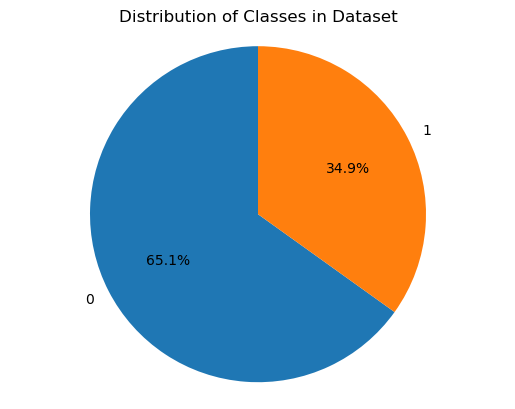

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
class_counts = data['Outcome'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Classes in Dataset')
plt.axis('equal') 
plt.show()

<Axes: >

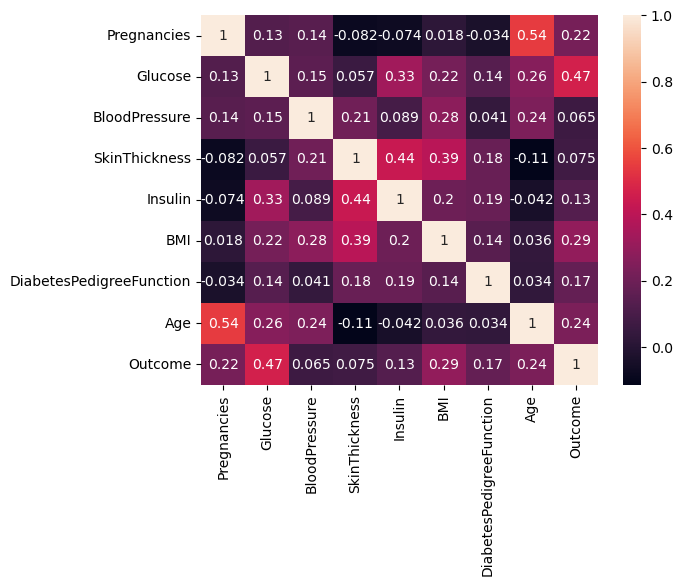

In [4]:
sns.heatmap(data.corr(), annot= True)

In [5]:
# Replacing 0 with Nan
data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

In [6]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# Defining function for different models

In [7]:
def train_and_predict(x, y, model):
    
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
    
    
    if model == 'random_forest':
        clf = RandomForestClassifier(n_estimators=16, max_depth=5, criterion='gini' ,random_state=0)
        paper_precision = 0
        paper_recall = 0
        paper_f1 = 0
        paper_accuracy = 0
    elif model == 'knn':
        clf = KNeighborsClassifier()
        paper_precision = 0.6 
        paper_recall = 0.69
        paper_f1 = 0.64
        paper_accuracy = 0.77
    elif model == 'decision_tree':
        clf = DecisionTreeClassifier(random_state=0)
        paper_precision = 0.63 
        paper_recall = 0.68
        paper_f1 = 0.65
        paper_accuracy = 0.76
    elif model == 'xgboost':
        clf = XGBClassifier(random_state=0)
        paper_precision = 0.6 
        paper_recall = 0.73
        paper_f1 = 0.65
        paper_accuracy = 0.77
    elif model == 'svc':
        clf = SVC()
        paper_precision = 0.6 
        paper_recall = 0.72
        paper_f1 = 0.65
        paper_accuracy = 0.77
    elif model == 'logistic_regression':
        clf = LogisticRegression()
        paper_precision = 0
        paper_recall = 0
        paper_f1 = 0
        paper_accuracy = 0

    else:
        print("Invalid model specified!")
        return None
    
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    
   
    
    
    
    
    precision = round(precision_score(y_test, predictions), 2)
    recall = round(recall_score(y_test, predictions), 2)
    f1 = round(f1_score(y_test, predictions), 2)
    accuracy = round(accuracy_score(y_test, predictions), 2)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    fpr = round(fp / (fp + tn), 2)

    
    print('**',model,'**')
    error_rates = [precision, recall, f1, accuracy]
    print('precision_score:', precision)
    print('recall_score:', recall)
    print('f1_score:', f1)
    print('accuracy_score:',accuracy)
    print("False Positive Rate:", fpr)
   
    return accuracy

# Imputing missing values and finding best k  

In [8]:
from sklearn.impute import KNNImputer
for k in range (1,50):
    print('==',k,'==')
    knn_impute = KNNImputer(n_neighbors=k)
    data_imputed = knn_impute.fit_transform(data)
    print("Data after imputation:")
    data_imputed = pd.DataFrame(data_imputed, columns= ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness',	'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age',	'Outcome'])
    x_knn_imputed = data_imputed.drop('Outcome', axis = 1)
    y_knn_imputed = data_imputed['Outcome']
    models = ['random_forest','knn', 'decision_tree', 'xgboost','svc', 'logistic_regression']

    for i in models:
        train_and_predict(x_knn_imputed, y_knn_imputed, i)
    print('****************************************************')

== 1 ==
Data after imputation:
** random_forest **
precision_score: 0.74
recall_score: 0.68
f1_score: 0.71
accuracy_score: 0.83
False Positive Rate: 0.1
** knn **
precision_score: 0.56
recall_score: 0.53
f1_score: 0.54
accuracy_score: 0.73
False Positive Rate: 0.19
** decision_tree **
precision_score: 0.59
recall_score: 0.68
f1_score: 0.63
accuracy_score: 0.76
False Positive Rate: 0.21
** xgboost **
precision_score: 0.61
recall_score: 0.72
f1_score: 0.66
accuracy_score: 0.77
False Positive Rate: 0.21
** svc **
precision_score: 0.68
recall_score: 0.49
f1_score: 0.57
accuracy_score: 0.77
False Positive Rate: 0.1
** logistic_regression **
precision_score: 0.69
recall_score: 0.62
f1_score: 0.65
accuracy_score: 0.8
False Positive Rate: 0.12
****************************************************
== 2 ==
Data after imputation:
** random_forest **
precision_score: 0.69
recall_score: 0.66
f1_score: 0.67
accuracy_score: 0.81
False Positive Rate: 0.13
** knn **
precision_score: 0.56
recall_score: 0

Best k = 18

In [9]:
# Apply K = 18 on dataset
from sklearn.impute import KNNImputer
best_knn_impute = KNNImputer(n_neighbors=18)
best_data_imputed = best_knn_impute.fit_transform(data)
print("Best data preprocessing after imputation:")
best_data_imputed = pd.DataFrame(best_data_imputed, columns= ['Pregnancies',	'Glucose',	'BloodPressure',	'SkinThickness',	'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age',	'Outcome'])
best_data_imputed

Best data preprocessing after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,195.944444,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,63.333333,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,28.0,215.277778,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.000000,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.000000,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.000000,32.9,0.171,63.0,0.0
764,2.0,122.0,70.0,27.0,165.666667,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.0,112.000000,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,29.5,186.777778,30.1,0.349,47.0,1.0


In [10]:
best_x = best_data_imputed.drop('Outcome', axis = 1)
best_y = best_data_imputed['Outcome']

In [11]:
models = ['random_forest','knn', 'decision_tree', 'xgboost','svc', 'logistic_regression']

for i in models:
    train_and_predict(best_x, best_y, i)
    print('***********************************')

** random_forest **
precision_score: 0.79
recall_score: 0.72
f1_score: 0.76
accuracy_score: 0.86
False Positive Rate: 0.08
***********************************
** knn **
precision_score: 0.6
recall_score: 0.6
f1_score: 0.6
accuracy_score: 0.75
False Positive Rate: 0.18
***********************************
** decision_tree **
precision_score: 0.54
recall_score: 0.57
f1_score: 0.56
accuracy_score: 0.72
False Positive Rate: 0.21
***********************************
** xgboost **
precision_score: 0.64
recall_score: 0.72
f1_score: 0.68
accuracy_score: 0.79
False Positive Rate: 0.18
***********************************
** svc **
precision_score: 0.69
recall_score: 0.51
f1_score: 0.59
accuracy_score: 0.78
False Positive Rate: 0.1
***********************************
** logistic_regression **
precision_score: 0.69
recall_score: 0.66
f1_score: 0.67
accuracy_score: 0.81
False Positive Rate: 0.13
***********************************


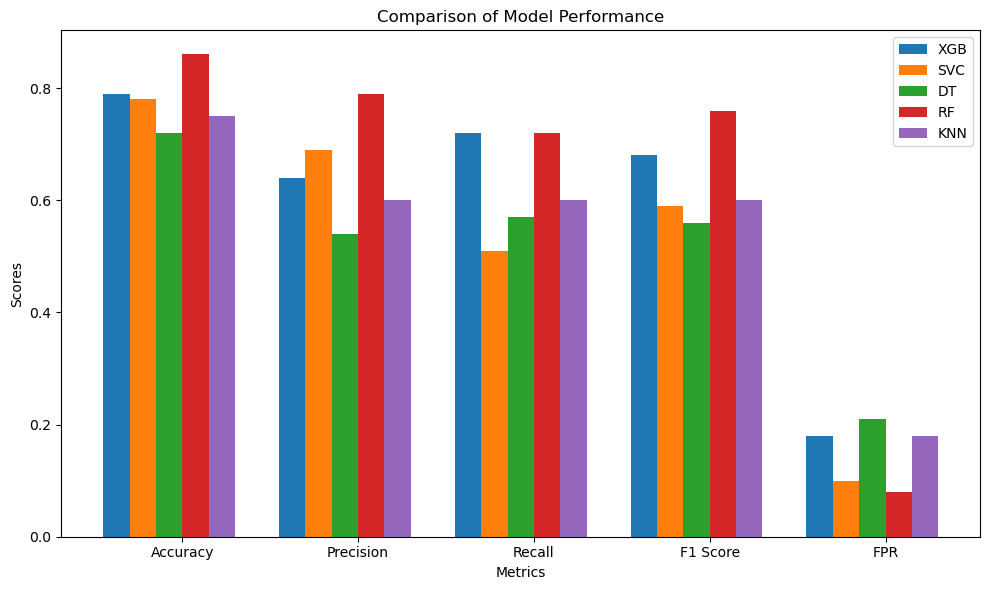

In [25]:
import matplotlib.pyplot as plt


results = {
    "XGB": {
        "Accuracy": 0.79,
        "Precision": 0.64,
        "Recall": 0.72,
        "F1 Score": 0.68,
        "FPR": 0.18
    },
    "SVC": {
        "Accuracy": 0.78,
        "Precision": 0.69,
        "Recall": 0.51,
        "F1 Score": 0.59,
        "FPR": 0.1
    },
    "DT": {
        "Accuracy": 0.72,
        "Precision": 0.54,
        "Recall": 0.57,
        "F1 Score": 0.56,
        "FPR": 0.21
    },
    "RF": {
        "Accuracy": 0.86,
        "Precision": 0.79,
        "Recall": 0.72,
        "F1 Score": 0.76,
        "FPR": 0.08
    },
    "KNN": {
        "Accuracy": 0.75,
        "Precision": 0.6,
        "Recall": 0.6,
        "F1 Score": 0.6,
        "FPR": 0.18
    }
}

models = list(results.keys())
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "FPR"]

data = np.array([[results[model][metric] for metric in metrics] for model in models])

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.15
index = np.arange(len(metrics))

for i, model in enumerate(models):
    ax.bar(index + i * bar_width, data[i], bar_width, label=model)


ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Performance')
ax.set_xticks(index + bar_width * len(models) / 2)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show()

Best model: Random forest

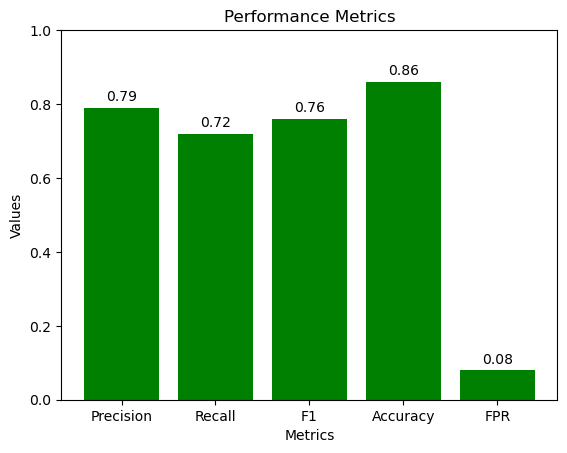

In [24]:
import numpy as np
import matplotlib.pyplot as plt


x = np.array(["Precision", "Recall", "F1", "Accuracy", 'FPR'])
y = np.array([0.79, 0.72, 0.76, 0.86, 0.08])

plt.bar(x, y, color='green')

for i, v in enumerate(y):
    plt.text(i, v + 0.01, f'{v}', ha='center', va='bottom')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Performance Metrics')
plt.ylim(0, 1)  
plt.show()


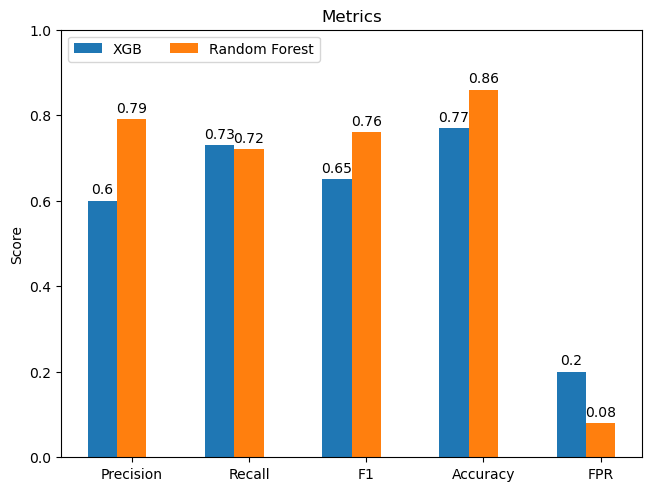

In [14]:
import matplotlib.pyplot as plt
import numpy as np

species = ("Precision", "Recall", "F1", "Accuracy", 'FPR')
penguin_means = {
    'XGB': (0.6, 0.73, 0.65, 0.77, 0.2),
    'Random Forest': (0.79, 0.72, 0.76, 0.86, 0.08 ),
    
}

x = np.arange(len(species))  
width = 0.25  
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1


ax.set_ylabel('Score')
ax.set_title('Metrics')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)

plt.show()

<Axes: >

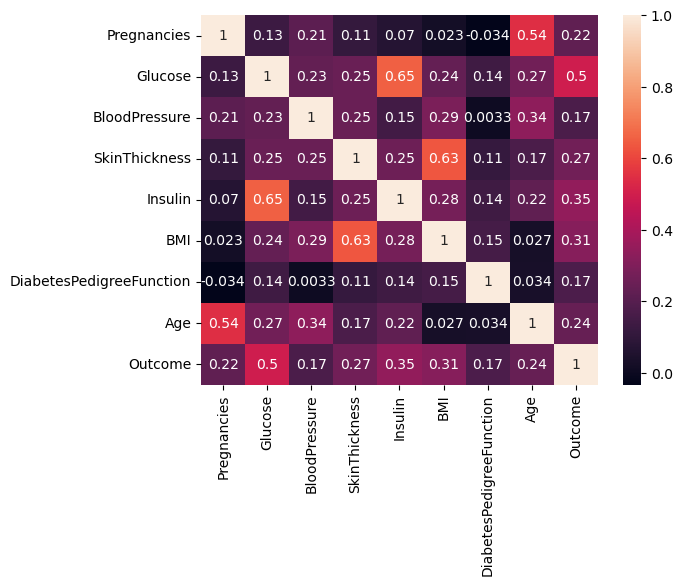

In [15]:
sns.heatmap(best_data_imputed.corr(), annot= True)

In [16]:
xx = best_data_imputed.drop('Outcome', axis = 1)
yy = best_data_imputed['Outcome']

xx_train, xx_test, yy_train, yy_test = train_test_split(xx, yy, test_size=0.2, random_state=0)
best_model = RandomForestClassifier(n_estimators=16, max_depth=5, criterion='gini' ,random_state=0)

best_model.fit(xx_train, yy_train)
yy_pred = best_model.predict(xx_test)



In [17]:
xx_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
661,1.0,199.0,76.0,43.000000,302.611111,42.9,1.394,22.0
122,2.0,107.0,74.0,30.000000,100.000000,33.6,0.404,23.0
113,4.0,76.0,62.0,26.833333,65.944444,34.0,0.391,25.0
14,5.0,166.0,72.0,19.000000,175.000000,25.8,0.587,51.0
529,0.0,111.0,65.0,23.388889,126.555556,24.6,0.660,31.0


# SHAP value

In [18]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(xx_train)
expected_value = explainer.expected_value
#just positive class
shap_values2 = shap_values[:,:,1]
shap_values2.shape

(614, 8)

# Global Explanations

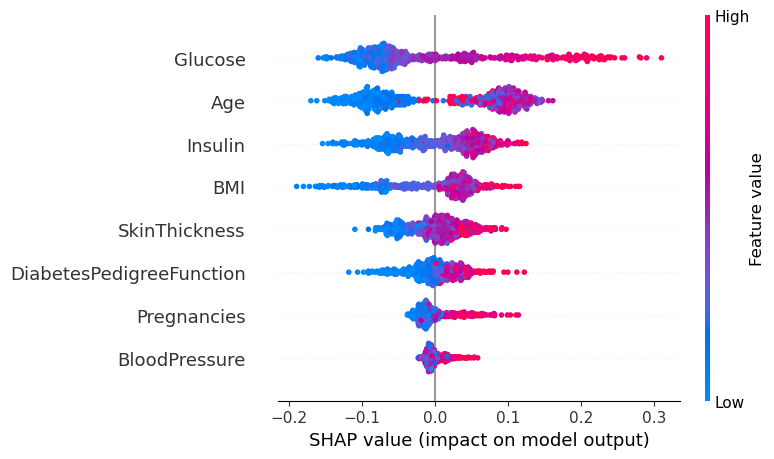

In [19]:
shap.summary_plot(shap_values2, xx_train)

# Global average explanation of RF model

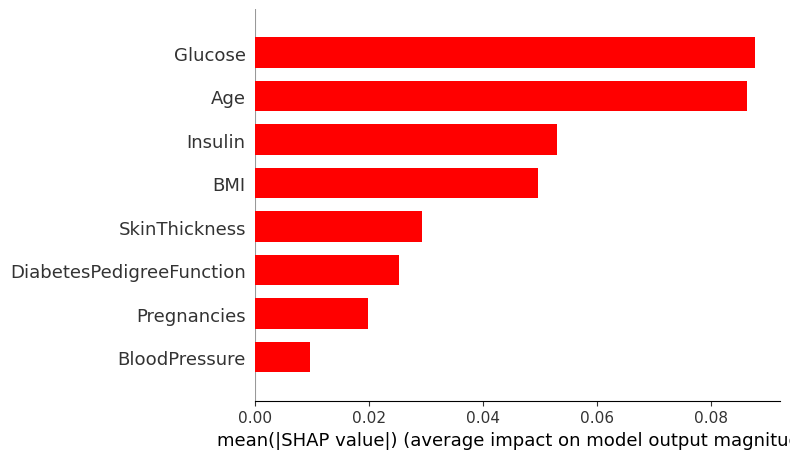

In [20]:
shap.summary_plot(shap_values2, xx_train, plot_type="bar", color='red')

# Feature dependencies plots

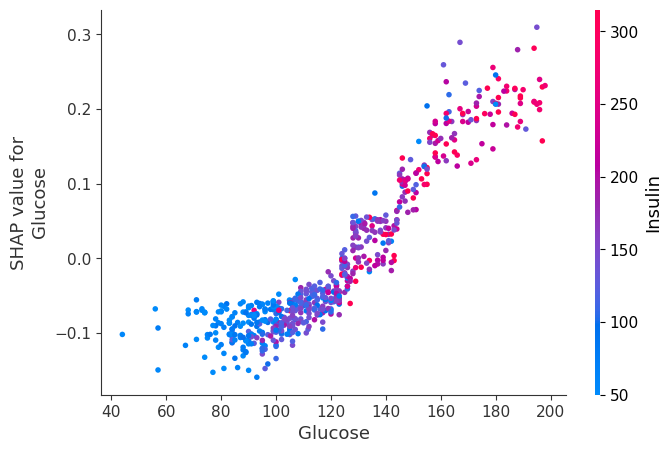

In [21]:
shap.dependence_plot('Glucose', shap_values2, xx_train, interaction_index='Insulin')

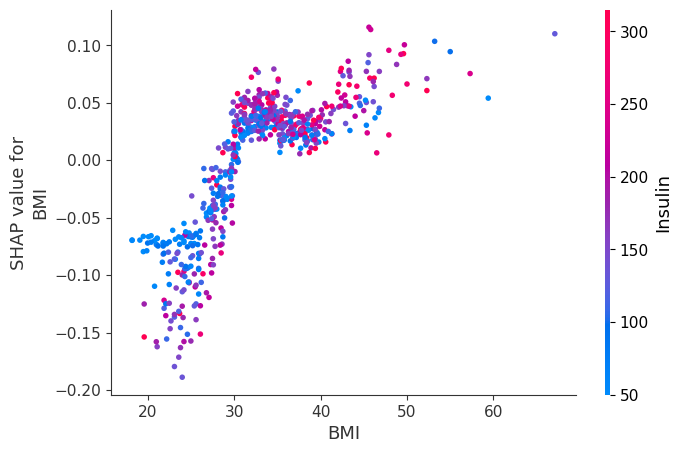

In [22]:
shap.dependence_plot('BMI', shap_values2, xx_train, interaction_index='Insulin')